In [112]:
# ––– Irish Financial Literacy Analysis ––––
# Companion analysis to the Excel dashboard
# Data source: OECD/INFE 2023 International Survey of Adult Financial Literacy
# Author: Lucy An Coffey | July 2026

# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import seaborn as sns

# Loading Data
# 18-29 country table
df = pd.read_excel("Irish_Financial_Literacy_Project.xlsx", sheet_name="05_Clean_Table")

# knowledge questions sheet
kq = pd.read_excel("Irish_Financial_Literacy_Project.xlsx", sheet_name="02_Knowledge_Questions")

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully")
print(f"Dataset loaded: {len(df)} countries")
print(f"Knowledge questions loaded: {len(kq)} questions")
print("\nIreland's 18-29 profile:")
print(df[df["Country"].str.strip() == "Ireland"][["Country", "Knowledge_Out_Of_100", "Behaviour_Out_Of_100", "Attitudes_Out_Of_100", "Overall_Score_Out_Of_100"]].to_string(index=False))

Libraries loaded successfully
Dataset loaded: 39 countries
Knowledge questions loaded: 5 questions

Ireland's 18-29 profile:
 Country  Knowledge_Out_Of_100  Behaviour_Out_Of_100  Attitudes_Out_Of_100  Overall_Score_Out_Of_100
Ireland              68.970192             75.686768             57.344543                 69.667519


In [113]:
# Colour Palette 
TEAL = "#0F6E56" # Ireland / primary
TEAL_LIGHT = "#E1F5EE" # Ireland background fills
GREY = "#B0B8B4" # OECD average
DARK = "#1A1A1A" # Text
AMBER = "#BA7517" # Warning / highlight
RED = "#A32D2D" # Below 50% threshold
PURPLE = "#3C3489" # Accent

In [114]:
# OECD averages for Ireland's 18-29 cohort (from 04_Analysis sheet)
OECD_18_29 = {
    "Knowledge":  62.71,
    "Behaviour":  60.14,
    "Attitudes":  54.94,
    "Overall":    60.01
}

# Ireland's 18-29 scores
IRE_18_29 = {
    "Knowledge":  68.97,
    "Behaviour":  75.69,
    "Attitudes":  57.34,
    "Overall":    69.67
}

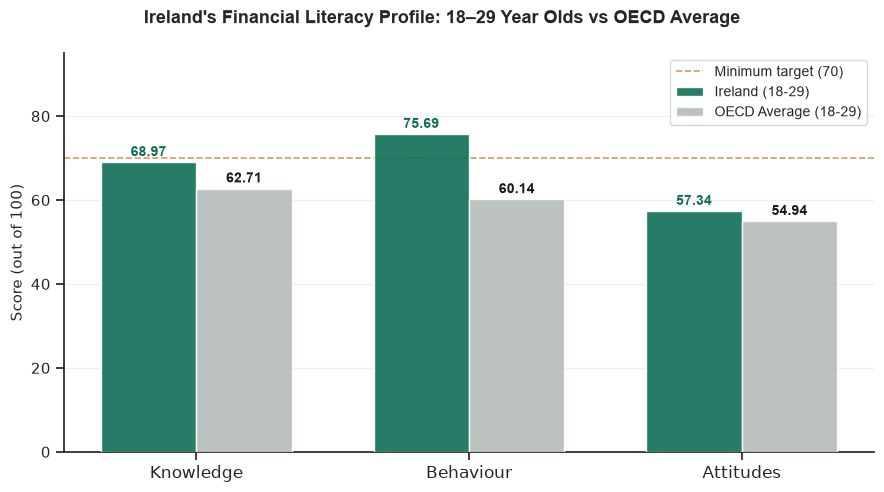

Chart 1 saved as chart1_ireland_profile.png


In [115]:
# --- Chart 1: Ireland 18-29 sub-score profile vs OECD ---

fig, ax = plt.subplots(figsize=(9, 5))

sns.set_theme(style='ticks')

metrics = ['Knowledge', 'Behaviour', 'Attitudes']
ire_scores = [IRE_18_29[m] for m in metrics]
oecd_scores = [OECD_18_29[m] for m in metrics]

x = [0, 1, 2]
width = 0.35

bars_ire = ax.bar([i - width/2 for i in x], ire_scores, width, label="Ireland (18-29)", color=TEAL, alpha=0.9, zorder=3)
bars_oecd = ax.bar([i + width/2 for i in x], oecd_scores, width, label="OECD Average (18-29)", color=GREY, alpha=0.85, zorder=3)

for bar in bars_ire:
    ax.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=TEAL)

for bar in bars_oecd:
    ax.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=DARK)

# Minimum target line
ax.axhline(y=70, color=AMBER, linestyle='--', linewidth=1.2, alpha=0.7, label='Minimum target (70)', zorder=2)

ax.set_ylabel('Score (out of 100)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_ylim(0, 95)

fig.suptitle("Ireland's Financial Literacy Profile: 18–29 Year Olds vs OECD Average", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('chart1_ireland_profile.png')
plt.show()
print("Chart 1 saved as chart1_ireland_profile.png")

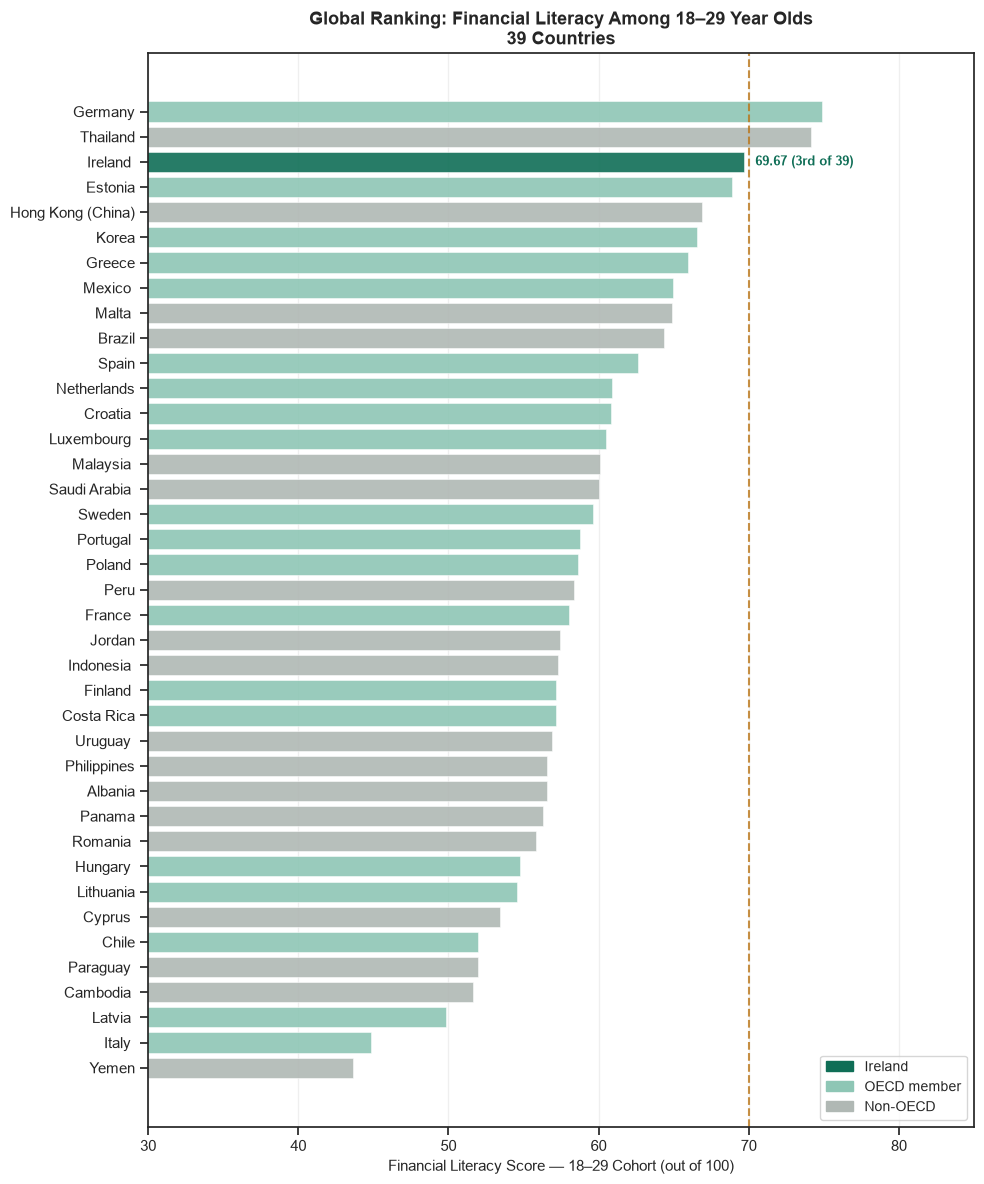

Chart 2 saved as chart2_global_ranking.png


In [116]:
# --- Chart 2: Global ranking of 18-29 cohorts ---

df_sorted = df.sort_values("Overall_Score_Out_Of_100", ascending=True).copy()

# Colour code
def bar_colour(row):
    if row["Country"] == 'Ireland ':
        return TEAL
    elif row['OECD_Member'] == 'Yes':
        return '#8EC6B5' 
    else:
        return GREY

df_sorted['bar_colour'] = df_sorted.apply(bar_colour, axis=1)

fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(
    df_sorted['Country'], 
    df_sorted['Overall_Score_Out_Of_100'], 
    color=df_sorted['bar_colour'], 
    alpha=0.9, edgecolor='white', linewidth=0.4)

# Setting minimum target reference line
ax.axvline(x=70, 
           color=AMBER, 
           linestyle='--', linewidth=1.5, alpha=0.8, 
           label='Minimum target (70)')

# Labelling Ireland's bar
ireland_score = df_sorted[df_sorted['Country'] == 'Ireland ']['Overall_Score_Out_Of_100'].values[0]
ireland_rank = int(df_sorted[df_sorted['Country'] == 'Ireland '].index[0])
ax.text(ireland_score + 0.5, 
        df_sorted['Country'].tolist().index('Ireland '), 
        f' {ireland_score:.2f} (3rd of 39)', 
        va='center', fontsize=9, fontweight='bold', color=TEAL)

# Legend patches
ire_patch = mpatches.Patch(color=TEAL,         label='Ireland')
oecd_patch = mpatches.Patch(color='#8EC6B5', label='OECD member')
other_patch = mpatches.Patch(color=GREY,       label='Non-OECD')

ax.set_xlabel('Financial Literacy Score — 18–29 Cohort (out of 100)', fontsize=11)
ax.set_title('Global Ranking: Financial Literacy Among 18–29 Year Olds\n39 Countries', fontsize=13, fontweight='bold')
ax.legend(handles=[ire_patch, oecd_patch, other_patch], loc='lower right', fontsize=10)
ax.set_xlim(30, 85)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_global_ranking.png')
plt.show()
print("Chart 2 saved as chart2_global_ranking.png")

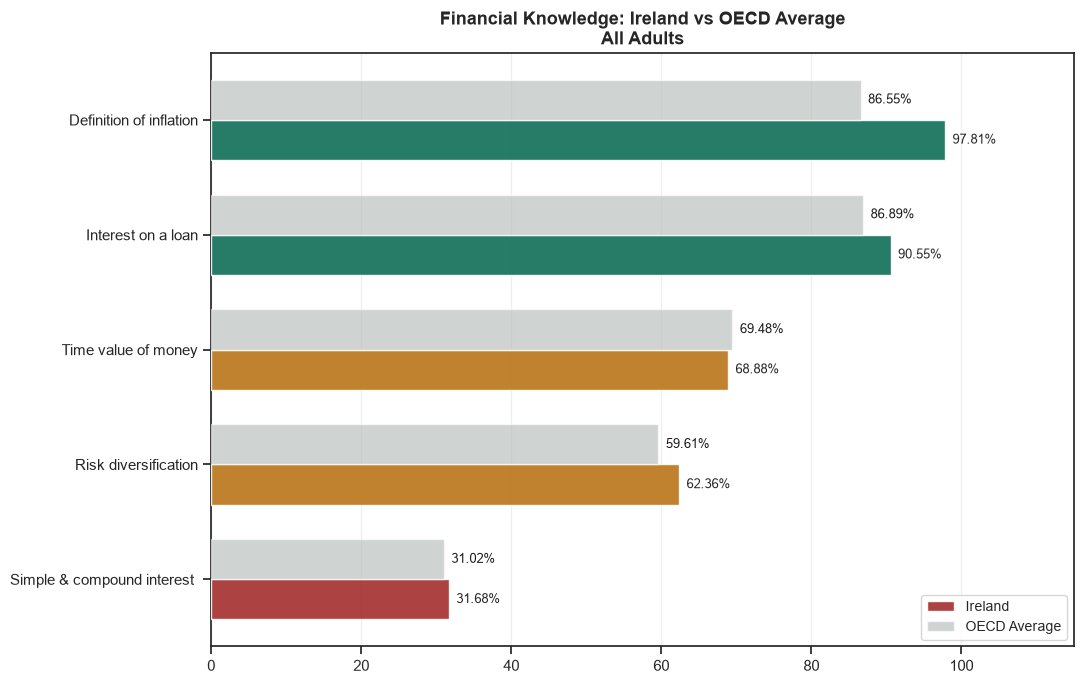

Chart 3 saved as chart3_knowledge_questions.png


In [117]:
# --- Chart 3: Knowledge question performance ---

# Sorting lowest to highest Ireland score
kq_sorted = kq.sort_values('Ireland % Correct', ascending=True).copy()

# Colour code
def kq_colour(score):
    if score < 50:
        return RED
    elif score < 70:
        return AMBER
    else:
        return TEAL

kq_sorted['bar_colour'] = kq_sorted['Ireland % Correct'].apply(kq_colour)

fig, ax = plt.subplots(figsize=(11, 7))

y = [0, 1, 2, 3, 4]
height = 0.35

# Ireland bars
bars_ire = ax.barh(
    [i - height/2 for i in y],
    kq_sorted['Ireland % Correct'], height=height, color=kq_sorted['bar_colour'], 
    alpha=0.9, label='Ireland', zorder=3)

# OECD bars
bars_oecd = ax.barh(
    [i + height/2 for i in y], 
    kq_sorted['OECD Average %'], height=height, color=GREY, 
    alpha=0.6, label='OECD Average', zorder=3)

# Value labels
for bar in bars_ire:
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va="center",
        fontsize=9
    )

for bar in bars_oecd:
      ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va="center",
        fontsize=9,
        color=DARK
    )  

ax.set_yticks(y)
ax.set_yticklabels(kq_sorted['Question'])
ax.set_title('Financial Knowledge: Ireland vs OECD Average\nAll Adults',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 115)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart3_knowledge_questions.png')
plt.show()
print("Chart 3 saved as chart3_knowledge_questions.png")

C:\Users\lucya\AppData\Local\Temp\ipykernel_34500\3545623521.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ire_penalty = df[df_yp['Country'] == 'Ireland ']['Youth_Penalty'].values[0]


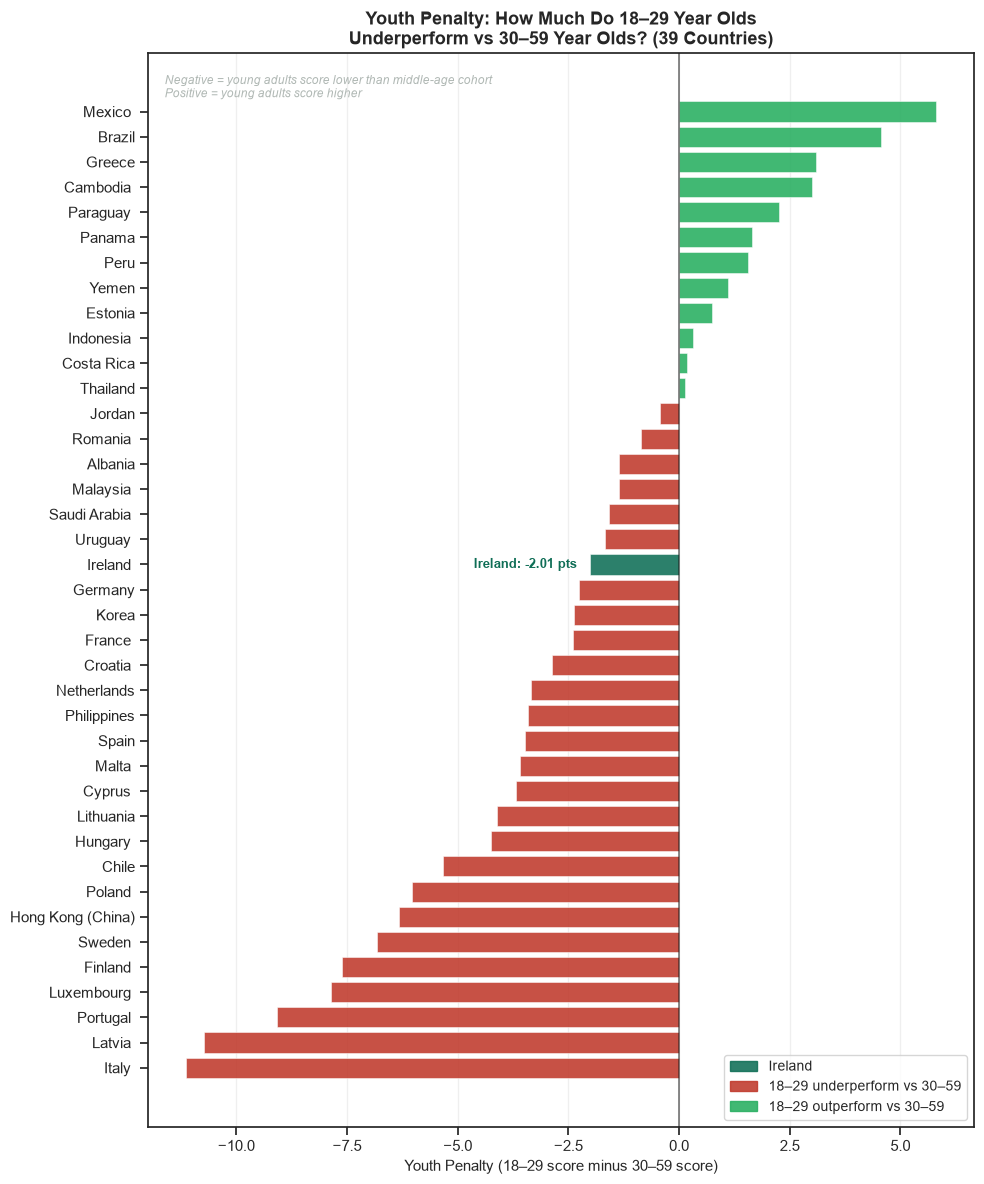

Chart 4 saved as chart4_youth_penalty.png


In [149]:
# Chart 4: Youth Penalty – 18-29 vs 30-59 cohort, all 39 countries ---
# Negative value = young adults underperform their middle-age counterparts

# Calculating youth penalty for all countries
df['Youth_Penalty'] = df['Score_18_29'] - df['Score_30_59']

# Sorting from most negative (worst youth penalty) to least
df_yp = df.sort_values('Youth_Penalty', ascending=True).copy()

# Colour code
def yp_colour(row):
    if row['Country'] == 'Ireland ':
        return TEAL
    elif row['Youth_Penalty'] < 0:
        return '#C0392B' 
    else:
        return '#27AE60'

df_yp['bar_colour'] = df_yp.apply(yp_colour, axis=1)

fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(
    df_yp['Country'],
    df_yp['Youth_Penalty'],
    color=df_yp['bar_colour'],
    alpha=0.88,
    edgecolor='white',
    linewidth=0.4
)

# Zero reference line
ax.axvline(x=0, color=DARK, linewidth=1.2, alpha=0.6, zorder=5)

# Labelling Ireland specifically
ire_penalty = df[df_yp['Country'] == 'Ireland ']['Youth_Penalty'].values[0]
ire_ypos = df_yp['Country'].tolist().index('Ireland ')

label_x = ire_penalty + 0.3 if ire_penalty >= 0 else ire_penalty - 0.3
ha      = 'left'            if ire_penalty >= 0 else 'right'

ax.text(label_x, ire_ypos,
        f'Ireland: {ire_penalty:+.2f} pts',
        va='center', ha=ha, fontsize=9.5,
        fontweight='bold', color=TEAL)

# Legend
neg_patch = mpatches.Patch(color='#C0392B', alpha=0.88,
                            label='18–29 underperform vs 30–59')
pos_patch = mpatches.Patch(color='#27AE60', alpha=0.88,
                            label='18–29 outperform vs 30–59')
ire_patch = mpatches.Patch(color=TEAL, alpha=0.88,
                            label='Ireland')

ax.set_xlabel('Youth Penalty (18–29 score minus 30–59 score)', fontsize=11)
ax.set_title('Youth Penalty: How Much Do 18–29 Year Olds\nUnderperform vs 30–59 Year Olds? (39 Countries)',
             fontsize=13, fontweight='bold')
ax.legend(handles=[ire_patch, neg_patch, pos_patch],
          loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

ax.text(0.02, 0.98,
        'Negative = young adults score lower than middle-age cohort\n'
        'Positive = young adults score higher',
        transform=ax.transAxes, fontsize=8.5,
        color=GREY, va='top', style='italic')

plt.tight_layout()
plt.savefig('chart4_youth_penalty.png')
plt.show()
print("Chart 4 saved as chart4_youth_penalty.png")